In [1]:
import fastf1


results = {}

schedule = fastf1.get_event_schedule(2024)


for race in schedule['EventName'].unique(): 
    session = fastf1.get_session(2024, race, 'Q')
    session.load()

    results[race] = session.results[['Abbreviation', 'TeamName', "Q1", "Q2", "Q3", "Position"]]


print(results)


req         WARNING 	DEFAULT CACHE ENABLED! (1.27 GB) /Users/jimmychavada/Library/Caches/fastf1
events      WARNING 	Correcting user input 'Pre-Season Testing' to 'Singapore Grand Prix'
core           INFO 	Loading data for Singapore Grand Prix - Qualifying [v3.5.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['4', '1', '44', '63', '81', '27', '14

{'Pre-Season Testing':    Abbreviation         TeamName                     Q1  \
4           NOR          McLaren 0 days 00:01:30.002000   
1           VER  Red Bull Racing 0 days 00:01:30.157000   
44          HAM         Mercedes 0 days 00:01:30.393000   
63          RUS         Mercedes 0 days 00:01:30.811000   
81          PIA          McLaren 0 days 00:01:30.258000   
27          HUL     Haas F1 Team 0 days 00:01:30.724000   
14          ALO     Aston Martin 0 days 00:01:30.684000   
22          TSU               RB 0 days 00:01:30.716000   
16          LEC          Ferrari 0 days 00:01:30.786000   
55          SAI          Ferrari 0 days 00:01:30.670000   
23          ALB         Williams 0 days 00:01:30.679000   
43          COL         Williams 0 days 00:01:30.704000   
11          PER  Red Bull Racing 0 days 00:01:30.624000   
20          MAG     Haas F1 Team 0 days 00:01:30.829000   
31          OCO           Alpine 0 days 00:01:30.958000   
3           RIC               RB 

In [2]:
import pandas as pd 

for race, df in results.items(): 
    df['Race'] = race

combined_df = pd.concat(results.values())


combined_df.to_csv("qualifying_results.csv", index=False)

df = pd.read_csv('qualifying_results.csv')

df.head()

/var/folders/06/7h6tpl3553lbp4vlf331z8z80000gn/T/ipykernel_8157/3748828827.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Race'] = race


,Abbreviation,TeamName,Q1,Q2,Q3,Position,Race
0,NOR,McLaren,0 days 00:01:30.002000,0 days 00:01:30.007000,0 days 00:01:29.525000,1.0,Pre-Season Testing
1,VER,Red Bull Racing,0 days 00:01:30.157000,0 days 00:01:29.680000,0 days 00:01:29.728000,2.0,Pre-Season Testing
2,HAM,Mercedes,0 days 00:01:30.393000,0 days 00:01:29.929000,0 days 00:01:29.841000,3.0,Pre-Season Testing
3,RUS,Mercedes,0 days 00:01:30.811000,0 days 00:01:30.153000,0 days 00:01:29.867000,4.0,Pre-Season Testing
4,PIA,McLaren,0 days 00:01:30.258000,0 days 00:01:29.640000,0 days 00:01:29.953000,5.0,Pre-Season Testing


In [3]:
races = df['Race'].unique()
drivers = df['Abbreviation'].unique()

qualy = {}

def safe_time_to_seconds(t):
    if pd.isna(t) or t in ['', '-', None]:
        return 0.0
    try:
        # convert to timedelta 
        if isinstance(t, str): 
            t = pd.to_timedelta(t)
        # If it's already a Timedelta → total_seconds
        if hasattr(t, 'total_seconds'):
            return t.total_seconds()
        # Else assume string "M:SS.sss" → parse
        if isinstance(t, str):
            m, s = t.split(":")
            return int(m) * 60 + float(s)
    except Exception as e:
        print(f"Failed to parse time: {t} ({e})")
        return 0.0

for race in races:
    for driver in drivers:

        # You need to define the series INSIDE the loop
        Q1_series = df[(df['Abbreviation'] == driver) & (df['Race'] == race)]['Q1']
        Q2_series = df[(df['Abbreviation'] == driver) & (df['Race'] == race)]['Q2']
        Q3_series = df[(df['Abbreviation'] == driver) & (df['Race'] == race)]['Q3']

        if not Q1_series.empty and not Q2_series.empty and not Q3_series.empty:


            Q1_value = safe_time_to_seconds(Q1_series.values[0])
            Q2_value = safe_time_to_seconds(Q2_series.values[0])
            Q3_value = safe_time_to_seconds(Q3_series.values[0])

            if driver not in qualy:
                qualy[driver] = []

            # Append this race result
            qualy[driver].append({
                race: {'Q1': Q1_value, 'Q2': Q2_value, 'Q3': Q3_value}
            })
        else:
            continue

# Pretty print result
import json
print(json.dumps(qualy, indent=2))


{
  "NOR": [
    {
      "Pre-Season Testing": {
        "Q1": 90.002,
        "Q2": 90.007,
        "Q3": 89.525
      }
    },
    {
      "Bahrain Grand Prix": {
        "Q1": 90.143,
        "Q2": 89.941,
        "Q3": 89.614
      }
    },
    {
      "Saudi Arabian Grand Prix": {
        "Q1": 88.805,
        "Q2": 88.479,
        "Q3": 88.132
      }
    },
    {
      "Australian Grand Prix": {
        "Q1": 77.43,
        "Q2": 76.75,
        "Q3": 76.315
      }
    },
    {
      "Japanese Grand Prix": {
        "Q1": 89.536,
        "Q2": 88.94,
        "Q3": 88.489
      }
    },
    {
      "Chinese Grand Prix": {
        "Q1": 94.842,
        "Q2": 94.46,
        "Q3": 94.165
      }
    },
    {
      "Miami Grand Prix": {
        "Q1": 87.913,
        "Q2": 87.871,
        "Q3": 87.594
      }
    },
    {
      "Emilia Romagna Grand Prix": {
        "Q1": 75.915,
        "Q2": 75.371,
        "Q3": 74.837
      }
    },
    {
      "Monaco Grand Prix": {
        "Q1":

In [4]:
# convert the qualy data into tabular format for processing 
rows = [] 
for driver, races in qualy.items(): 
    for race_data in races: 
        for race, times in race_data.items(): 
            row = { 
                "Driver": driver, 
                "Race": race,
                "Q1": times['Q1'],
                "Q2": times['Q2'],
                "Q3": times['Q3'],
            }
            rows.append(row)

print(json.dumps(rows, indent=2))
df_qualy = pd.DataFrame(rows)

[
  {
    "Driver": "NOR",
    "Race": "Pre-Season Testing",
    "Q1": 90.002,
    "Q2": 90.007,
    "Q3": 89.525
  },
  {
    "Driver": "NOR",
    "Race": "Bahrain Grand Prix",
    "Q1": 90.143,
    "Q2": 89.941,
    "Q3": 89.614
  },
  {
    "Driver": "NOR",
    "Race": "Saudi Arabian Grand Prix",
    "Q1": 88.805,
    "Q2": 88.479,
    "Q3": 88.132
  },
  {
    "Driver": "NOR",
    "Race": "Australian Grand Prix",
    "Q1": 77.43,
    "Q2": 76.75,
    "Q3": 76.315
  },
  {
    "Driver": "NOR",
    "Race": "Japanese Grand Prix",
    "Q1": 89.536,
    "Q2": 88.94,
    "Q3": 88.489
  },
  {
    "Driver": "NOR",
    "Race": "Chinese Grand Prix",
    "Q1": 94.842,
    "Q2": 94.46,
    "Q3": 94.165
  },
  {
    "Driver": "NOR",
    "Race": "Miami Grand Prix",
    "Q1": 87.913,
    "Q2": 87.871,
    "Q3": 87.594
  },
  {
    "Driver": "NOR",
    "Race": "Emilia Romagna Grand Prix",
    "Q1": 75.915,
    "Q2": 75.371,
    "Q3": 74.837
  },
  {
    "Driver": "NOR",
    "Race": "Monaco Grand 

In [5]:
df_qualy.head()

,Driver,Race,Q1,Q2,Q3
0,NOR,Pre-Season Testing,90.002,90.007,89.525
1,NOR,Bahrain Grand Prix,90.143,89.941,89.614
2,NOR,Saudi Arabian Grand Prix,88.805,88.479,88.132
3,NOR,Australian Grand Prix,77.430,76.750,76.315
4,NOR,Japanese Grand Prix,89.536,88.940,88.489


In [6]:
# If the driver has null values make sure they are 0 
df_qualy.isnull().sum()

Driver    0
Race      0
Q1        0
Q2        0
Q3        0
dtype: int64

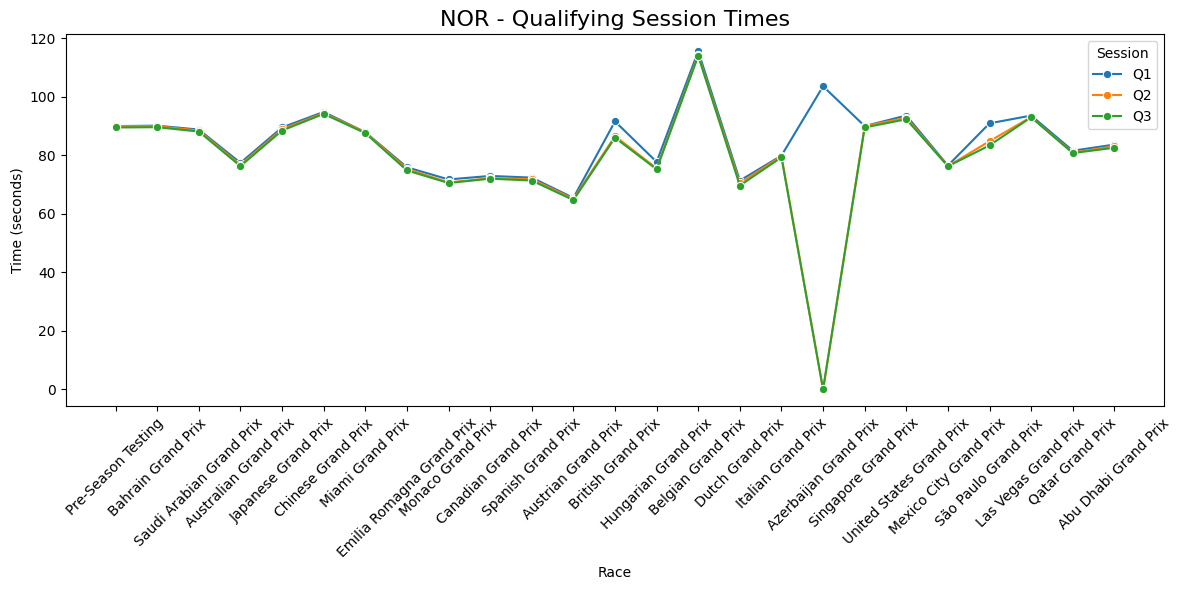

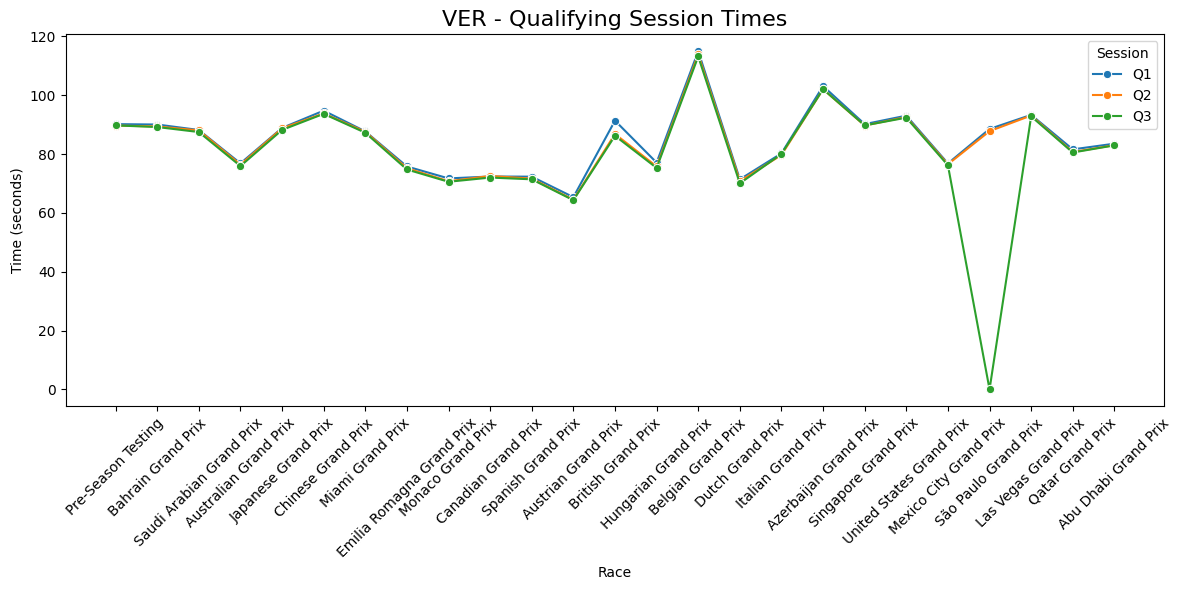

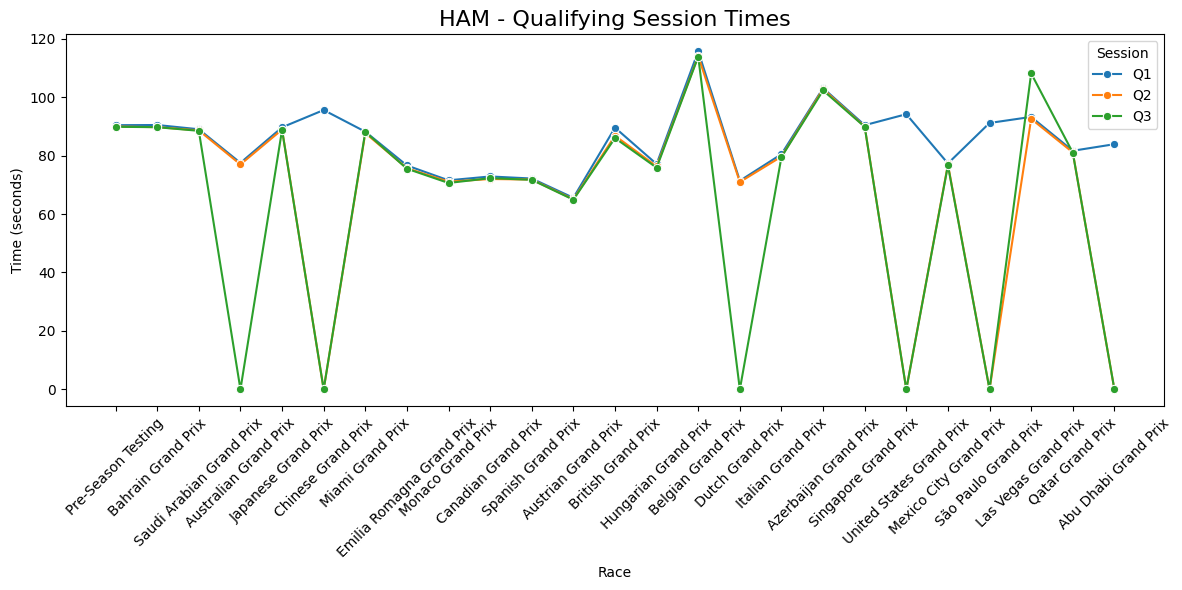

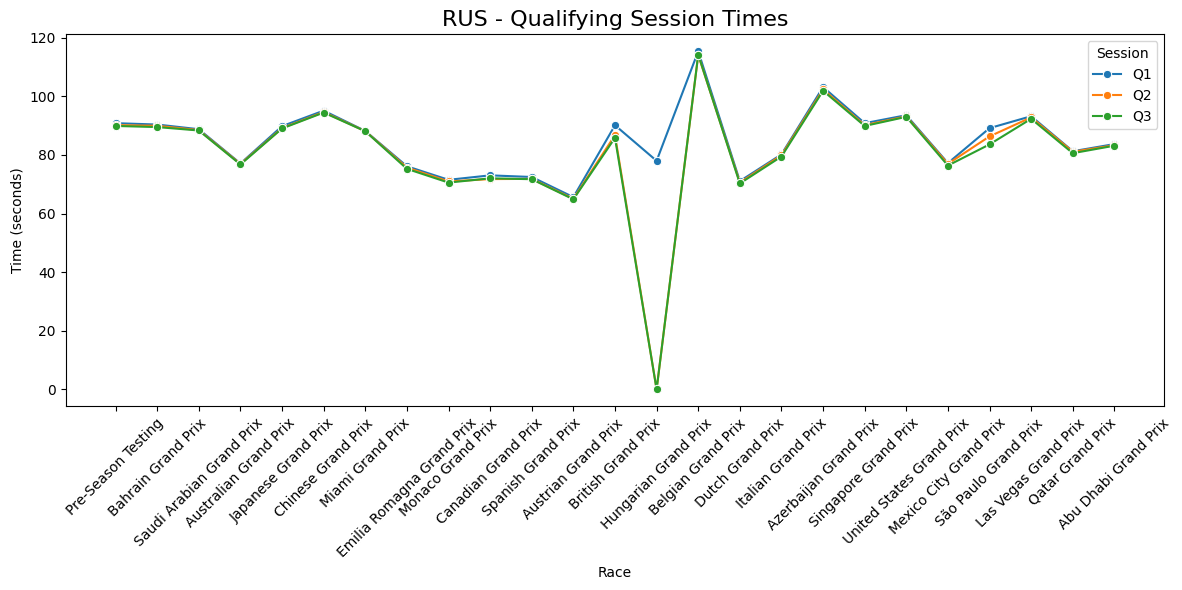

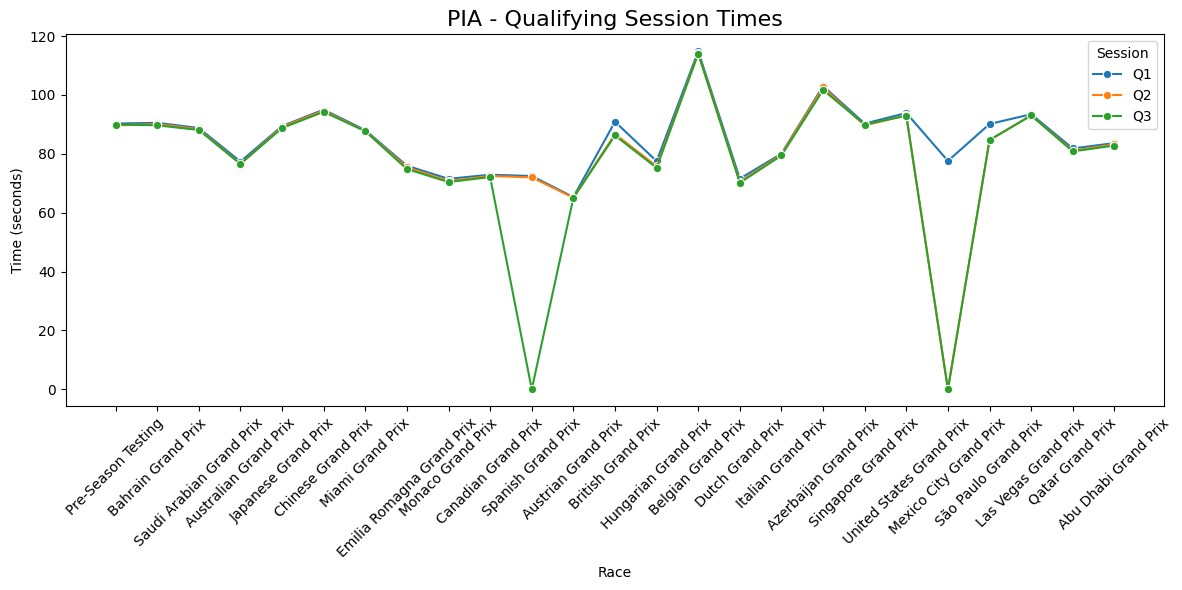

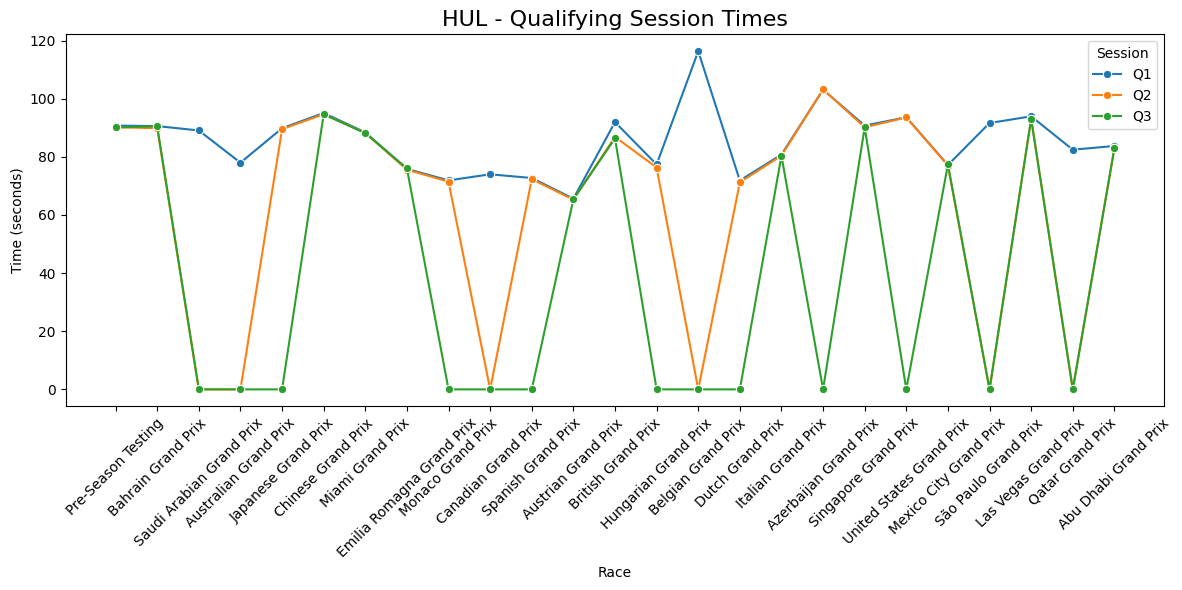

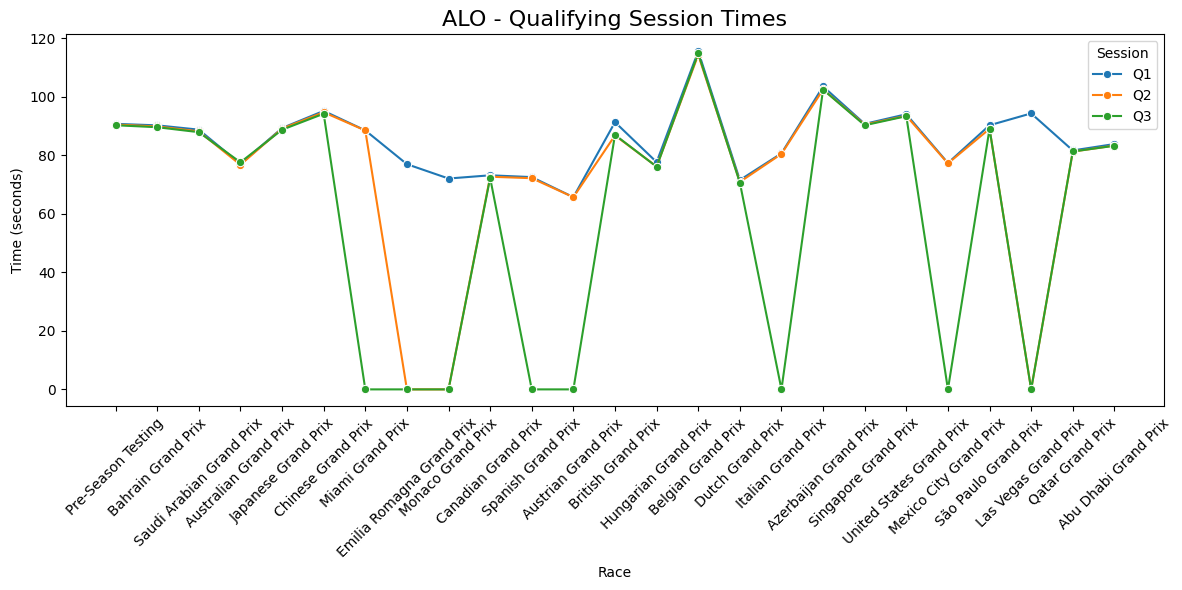

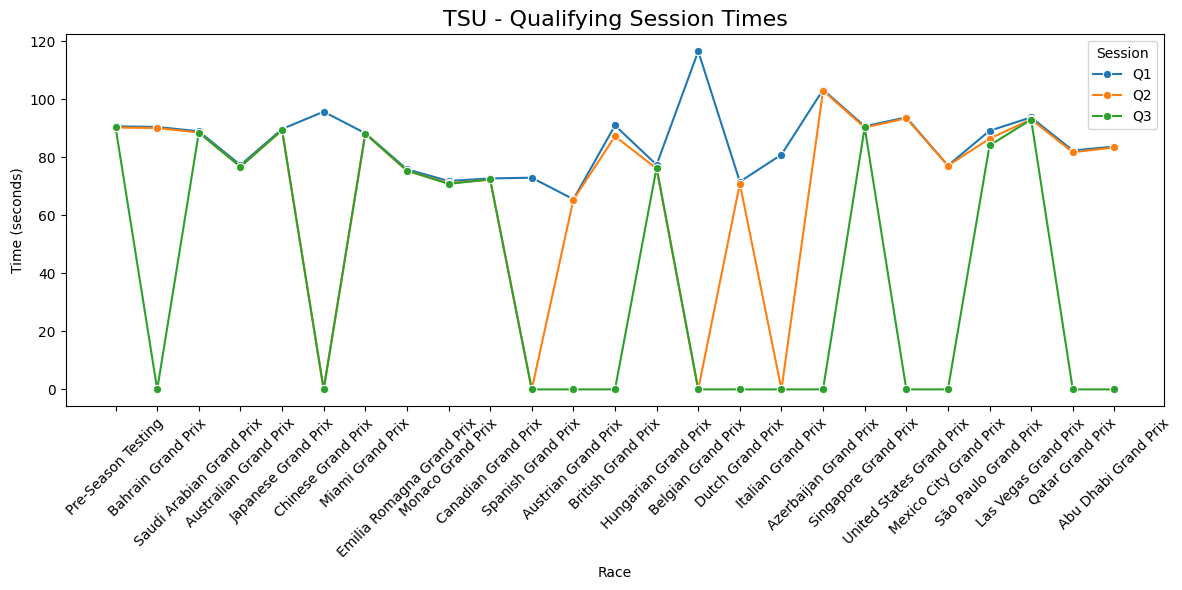

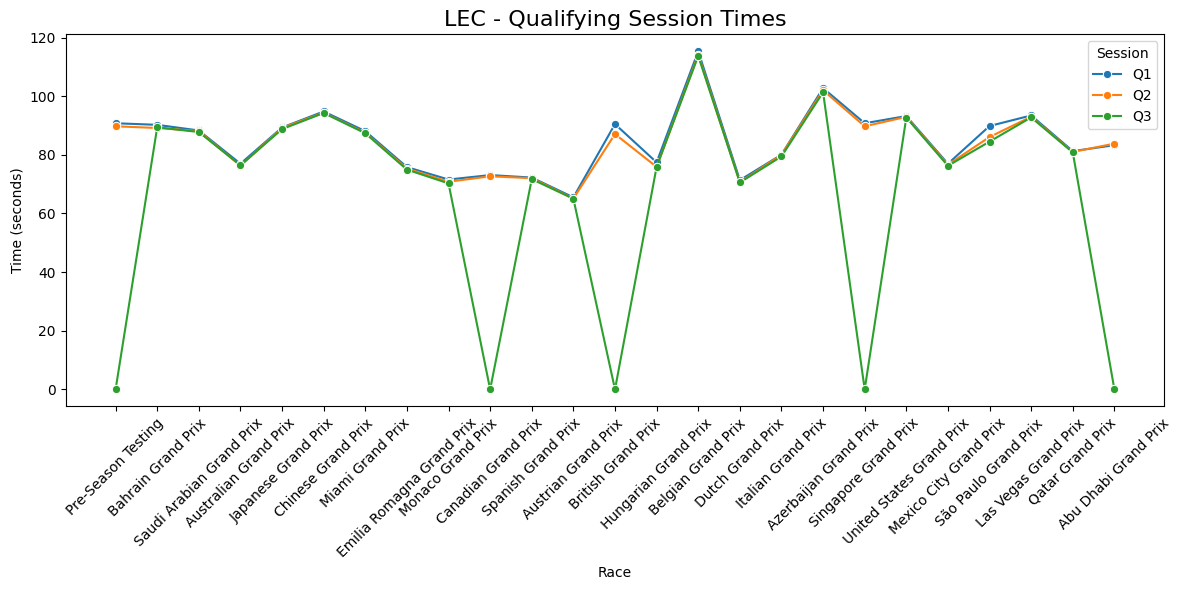

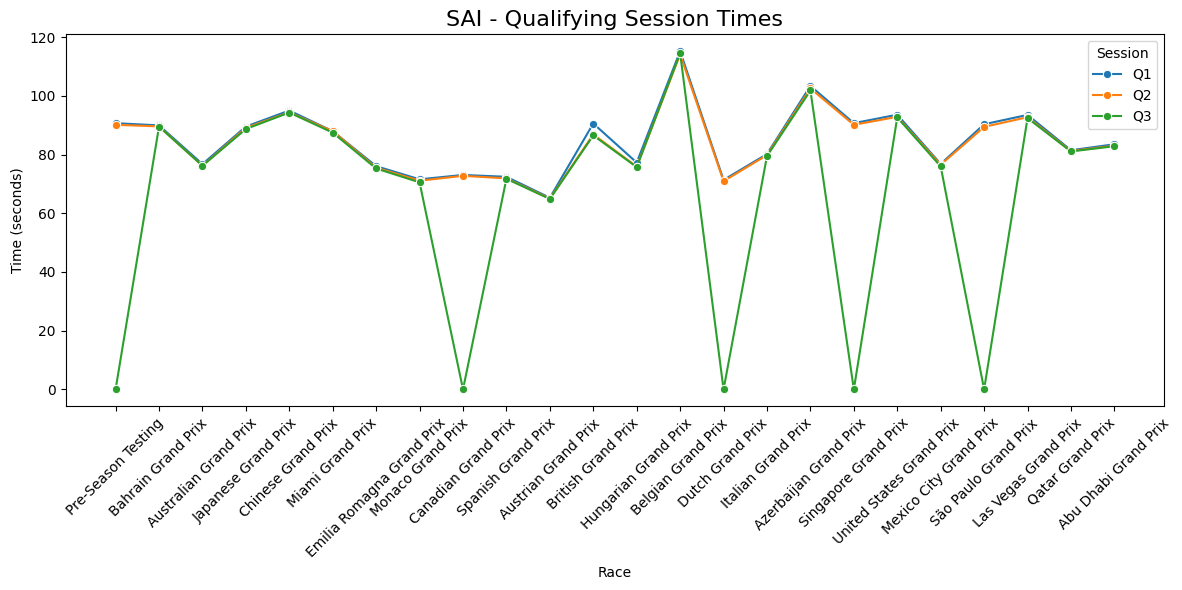

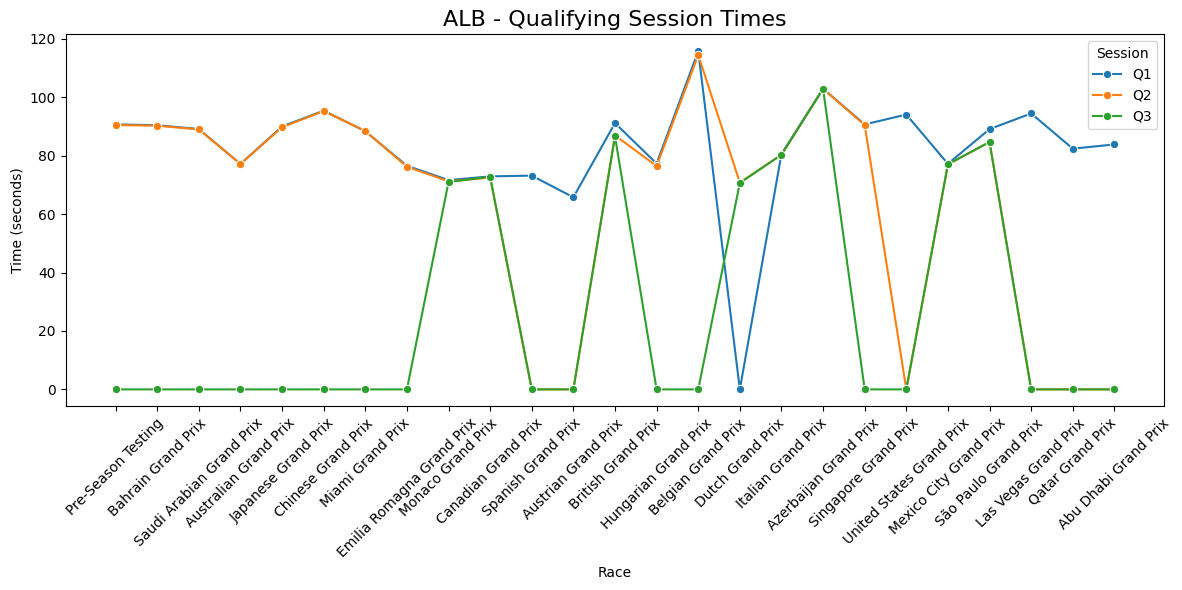

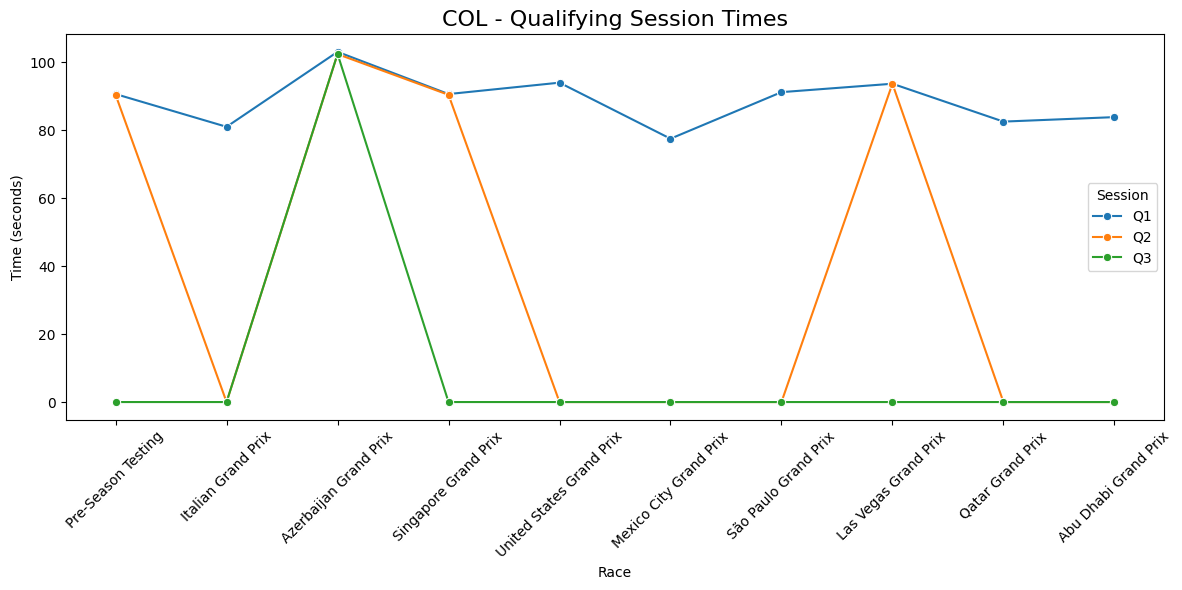

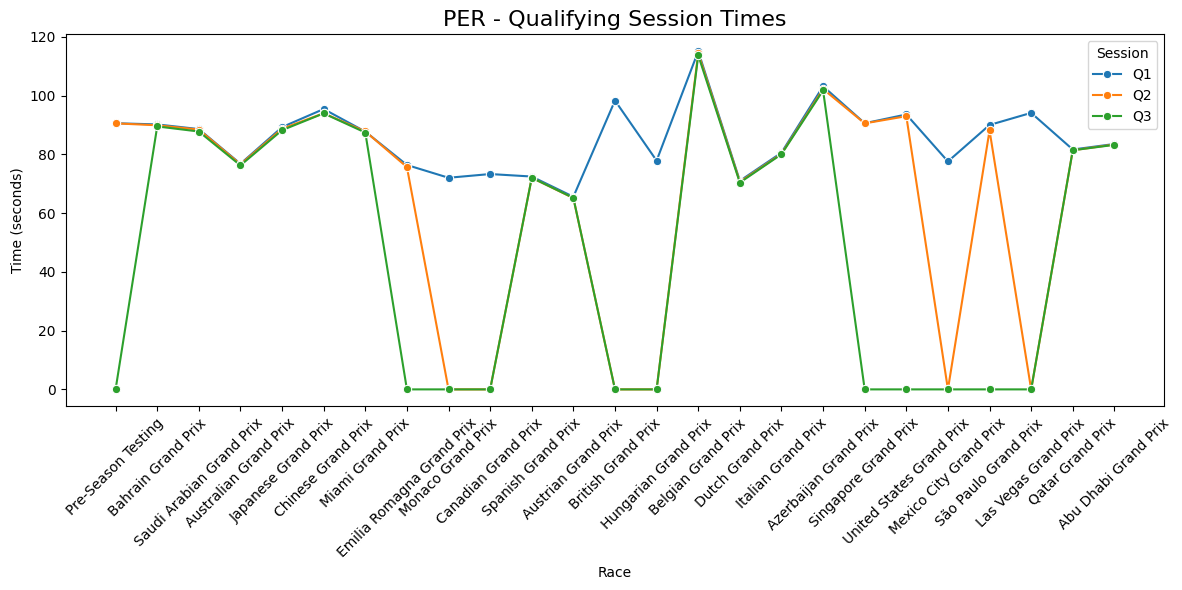

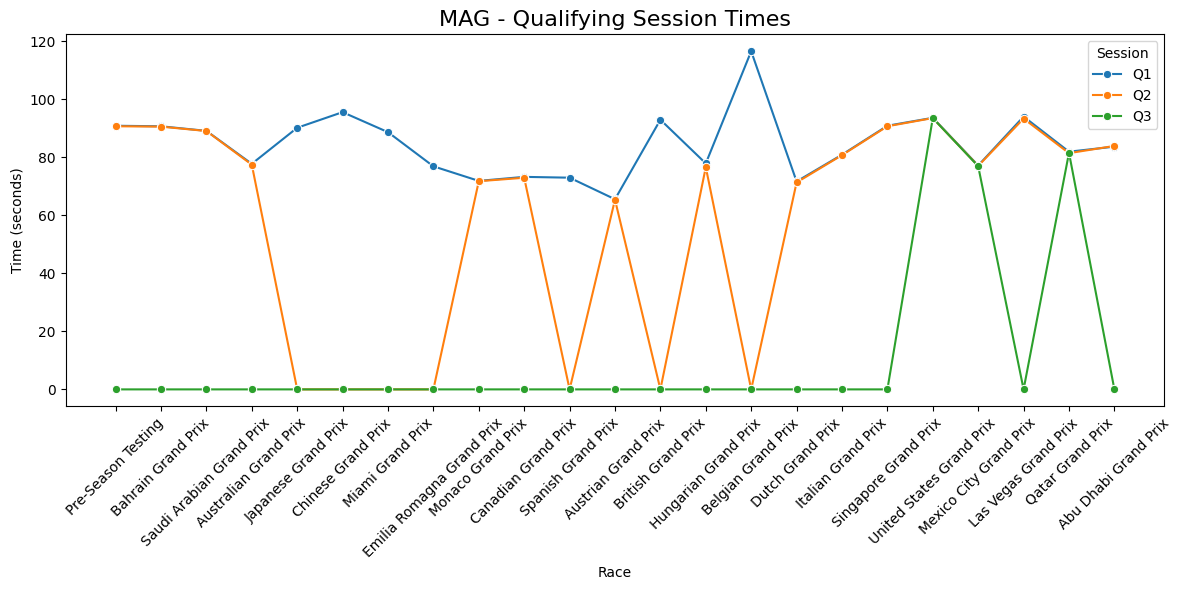

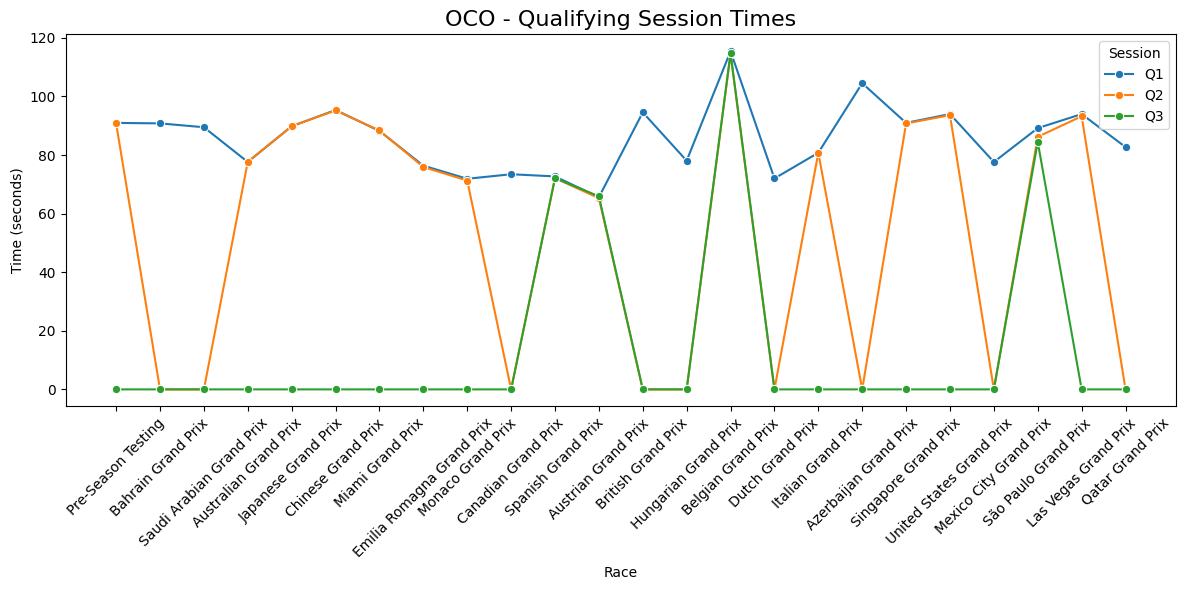

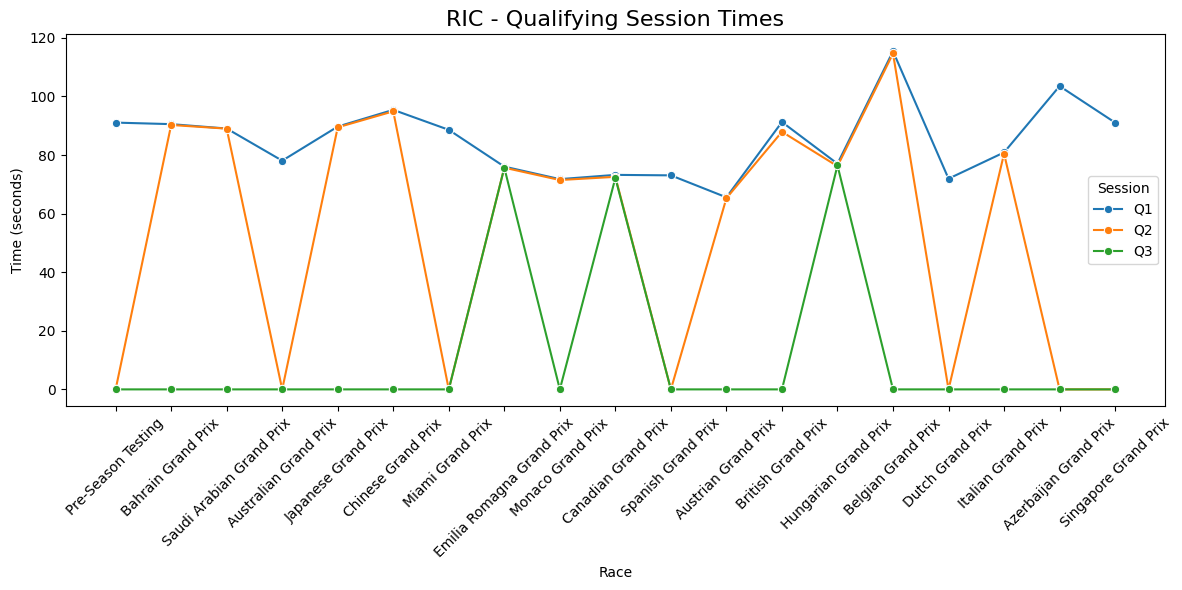

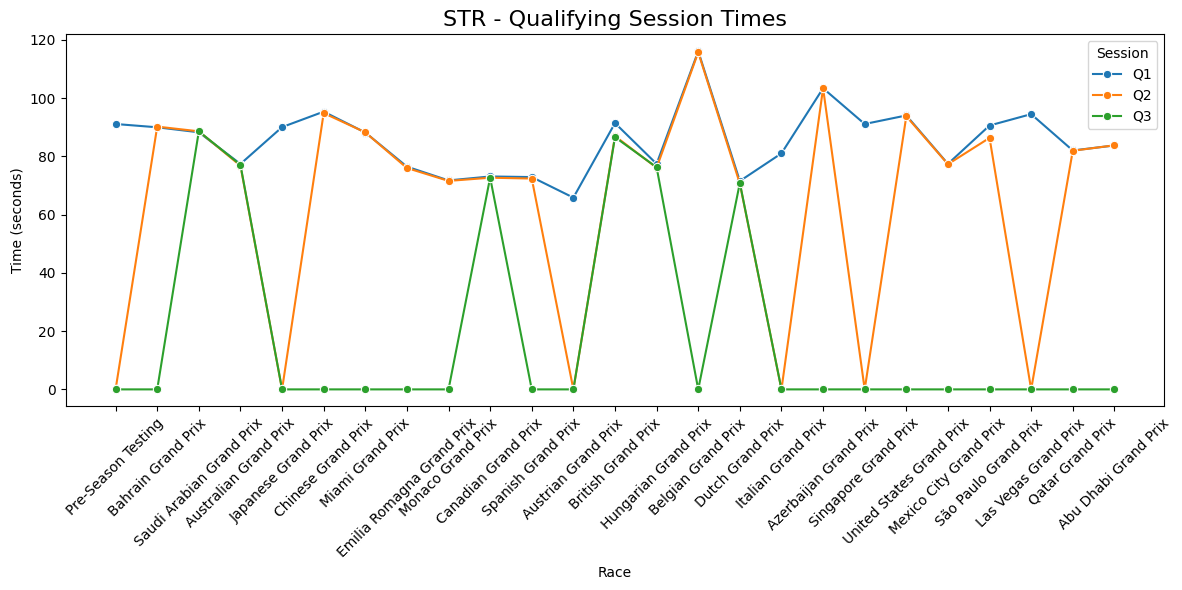

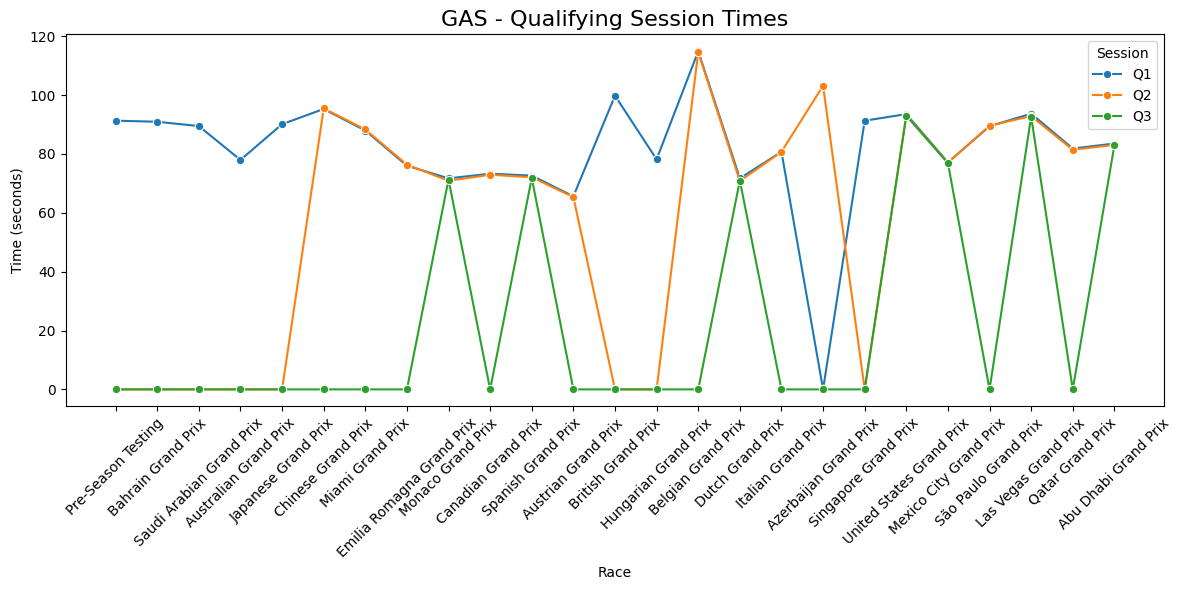

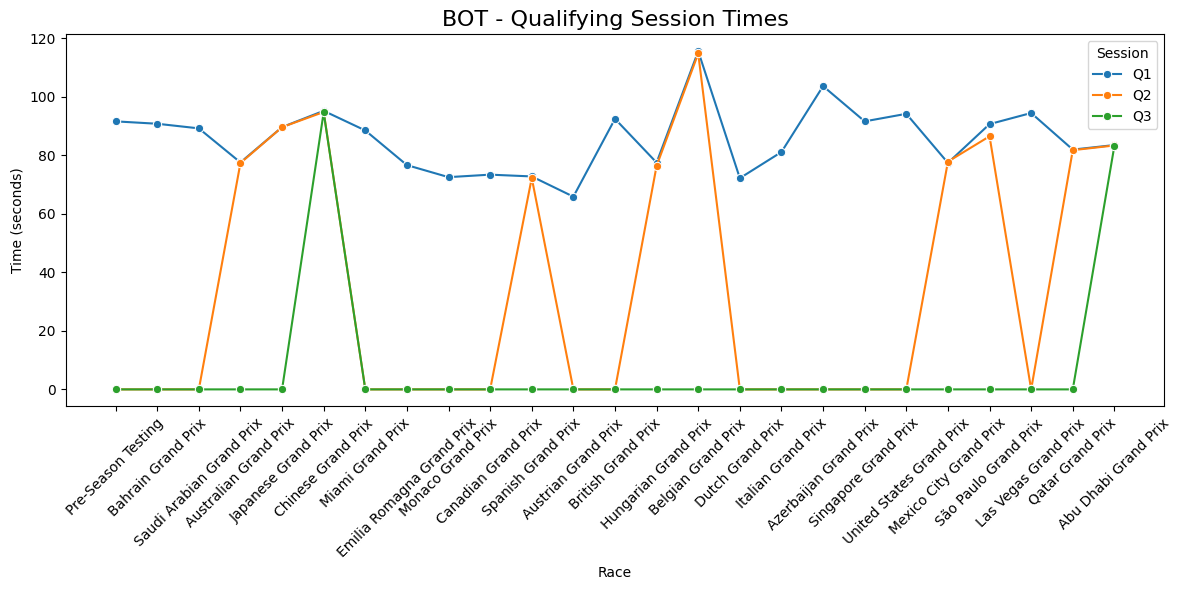

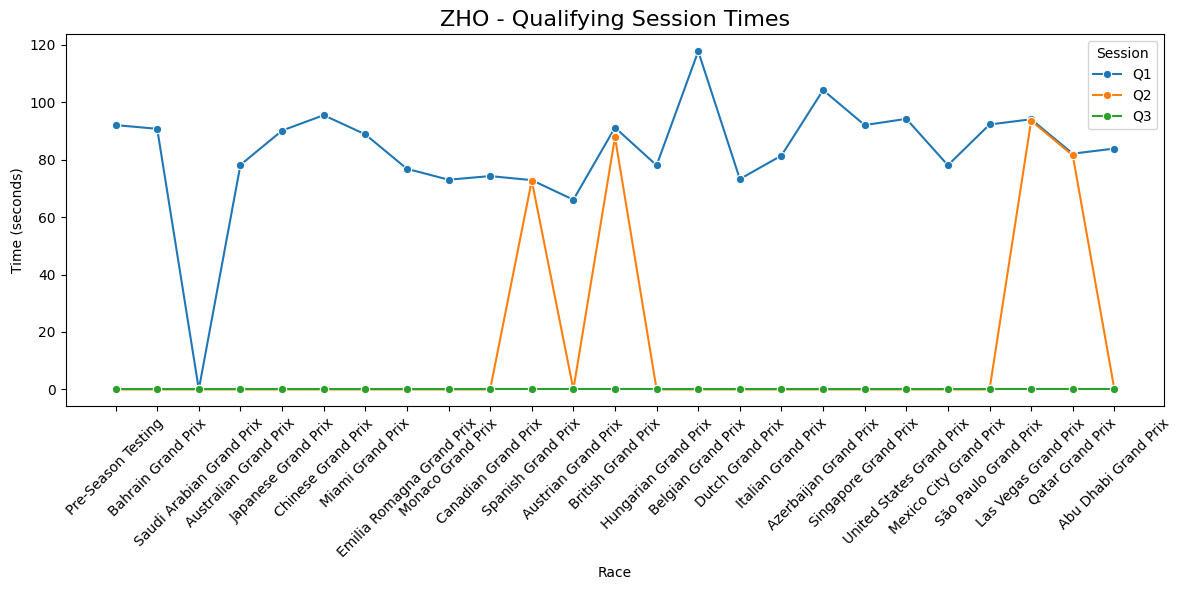

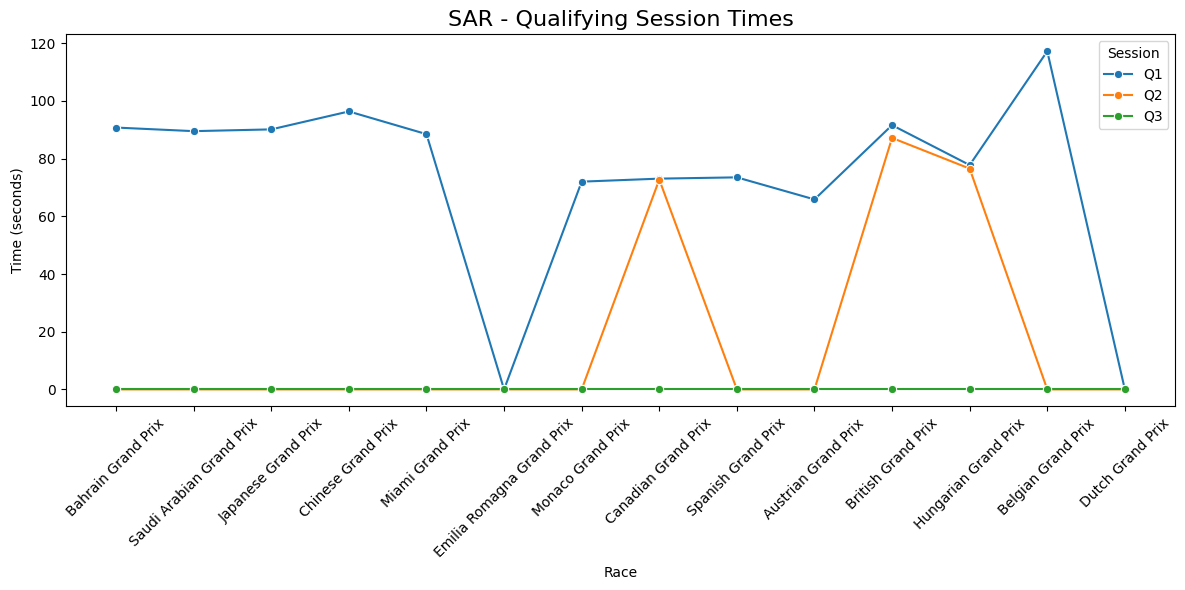

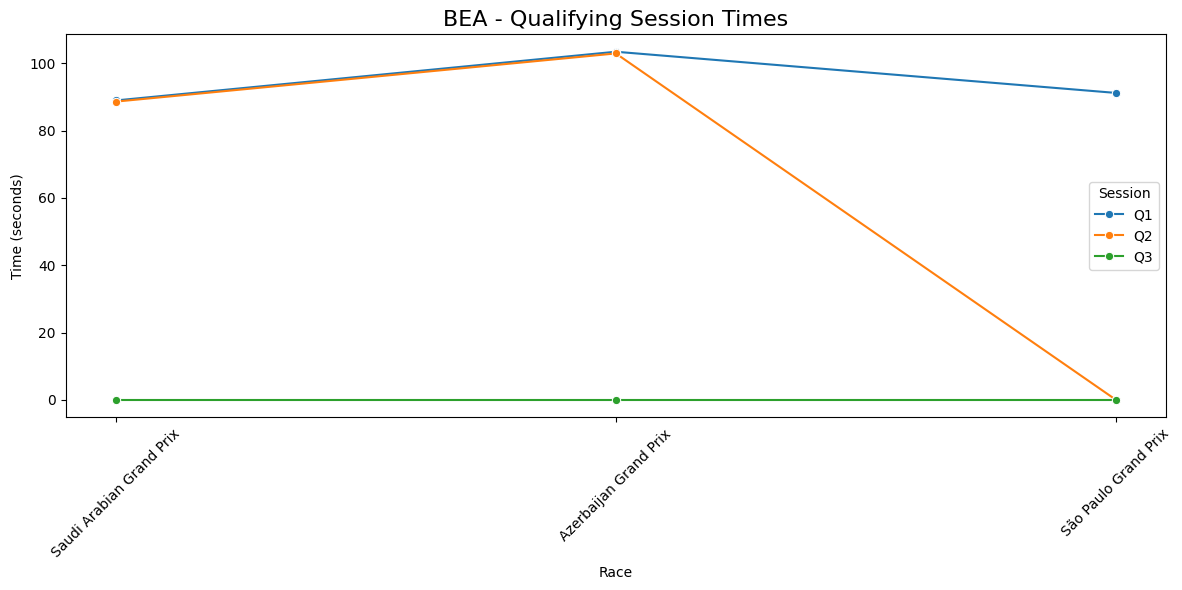

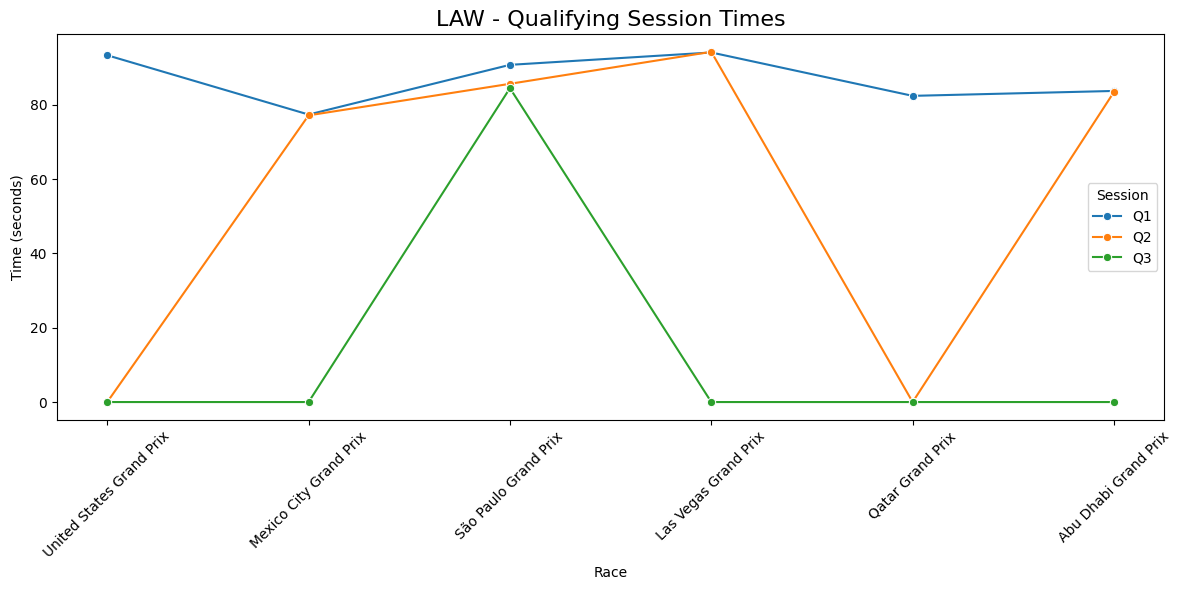

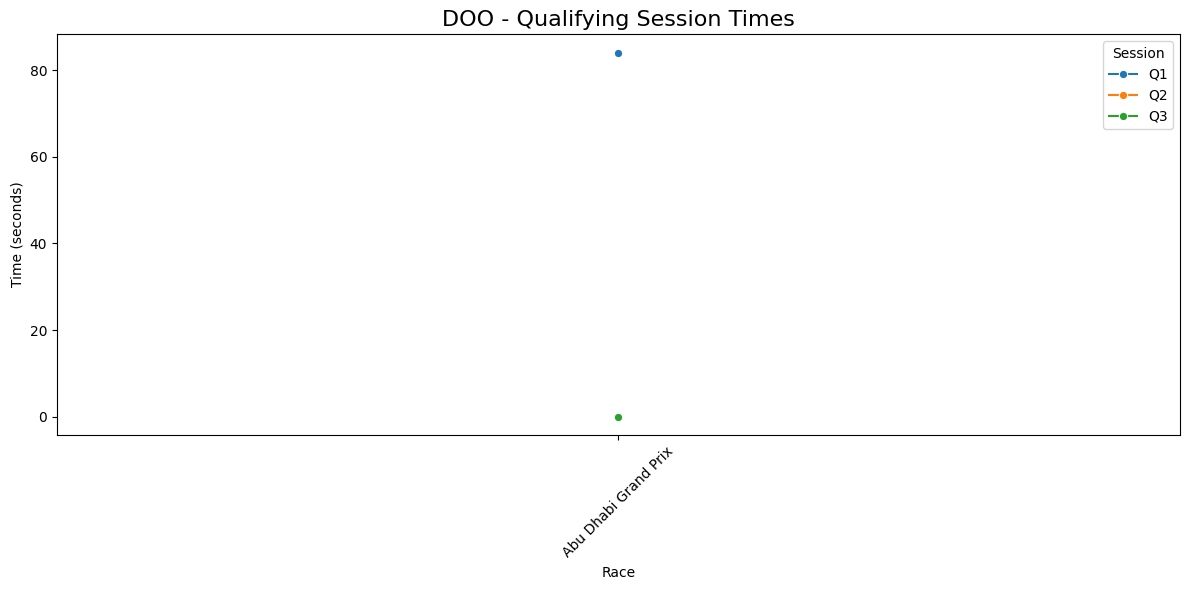

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns 

df_melted = df_qualy.melt(id_vars=["Driver", "Race"], value_vars=["Q1", "Q2", "Q3"],
                          var_name="Session", value_name="Time")

drivers = df_melted["Driver"].unique()


for driver in drivers: 
    plt.figure(figsize=(12,6))
    data = df_melted[df_melted['Driver'] == driver]

    sns.lineplot(data=data, x="Race", y="Time", hue="Session", marker='o')
    plt.title(f"{driver} - Qualifying Session Times", fontsize=16)
    plt.xticks(rotation=45)
    plt.ylabel("Time (seconds)")
    plt.xlabel("Race")
    plt.tight_layout()
    
    plt.show()  # Displays the plot for each driver



In [8]:
df_melted = df_melted[df_melted['Driver'] != "DOO"]


### Model Creation Section
This section outlines the steps to create a linear regression model starting with a single input model from Q1 qualifying in order to predict other sessions 

In [9]:
# Encode the name of the Drivers using one hot encoding 
df_encoded = pd.get_dummies(df_qualy, columns=['Driver'], prefix='Driver', dtype=int)
df_encoded = pd.get_dummies(df_encoded, columns=['Race'], prefix='Race', dtype=int)


df_encoded



,Q1,Q2,Q3,Driver_ALB,Driver_ALO,Driver_BEA,Driver_BOT,Driver_COL,Driver_DOO,Driver_GAS,...,Race_Mexico City Grand Prix,Race_Miami Grand Prix,Race_Monaco Grand Prix,Race_Pre-Season Testing,Race_Qatar Grand Prix,Race_Saudi Arabian Grand Prix,Race_Singapore Grand Prix,Race_Spanish Grand Prix,Race_São Paulo Grand Prix,Race_United States Grand Prix
0,90.002,90.007,89.525,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
1,90.143,89.941,89.614,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,88.805,88.479,88.132,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,77.430,76.750,76.315,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,89.536,88.940,88.489,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
494,90.758,85.654,84.484,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
495,94.087,94.257,0.000,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
496,82.411,0.000,0.000,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
497,83.733,83.472,0.000,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# Our X features will include engineered features 
# we need the race number previous qualyfing times, driver name 

# Lets remove the DNF values first 

df_q3_valid = df_encoded[df_encoded['Q3']>0]


y = df_q3_valid['Q3'] # we want to preidct the Q3 

X = df_q3_valid.drop(columns=['Q1', 'Q2', 'Q3'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
# Creat the linear regression model 
model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)


In [12]:
# evaluate the model 
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R² Score:", r2)

comparison = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

print(comparison.head(10))

Mean Squared Error: 0.43158288142707735
Mean Absolute Error: 0.41190591694565626
R² Score: 0.9961682129907274
     Actual  Predicted
25   89.728  89.492026
6    87.594  87.288768
193  90.354  89.865856
390  70.857  70.911303
422  92.664  95.331195
226  89.507  89.437099
307  81.425  80.864402
184  72.414  71.989745
9    72.021  71.478238
124  82.804  82.894573


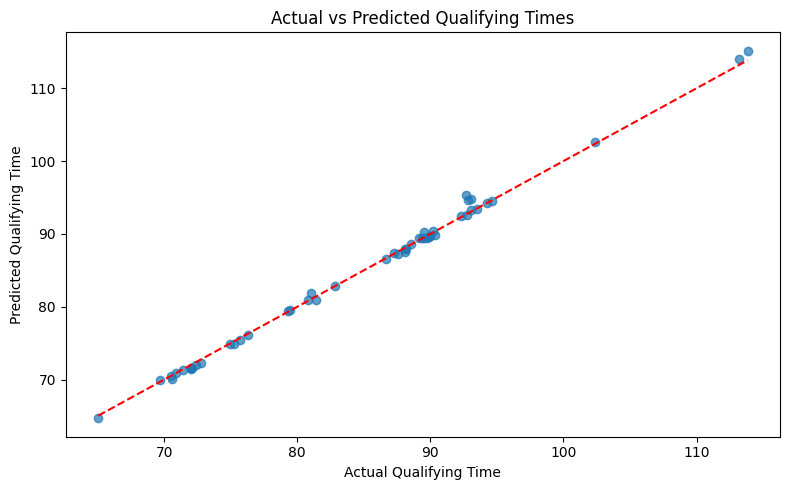

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel("Actual Qualifying Time")
plt.ylabel("Predicted Qualifying Time")
plt.title("Actual vs Predicted Qualifying Times")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.tight_layout()
plt.show()

In [14]:
print(y.describe())

count    243.000000
mean      83.945856
std       11.065295
min       64.314000
25%       75.685000
50%       84.111000
75%       89.841000
max      114.810000
Name: Q3, dtype: float64


In [15]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5, scoring='r2')
print("CV R² scores:", scores)
print("Mean R²:", scores.mean())


CV R² scores: [0.99526337 0.96102217 0.9934799  0.99519589 0.99804279]
Mean R²: 0.9886008261342372


In [16]:
# dropping driver name and testing again 
df_without_driver = df_encoded.drop(columns=df_encoded.columns[df_encoded.columns.str.contains("^Driver_")])


X = df_without_driver.drop(columns=["Q1", "Q2", "Q3"])
y = df_without_driver["Q3"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Retrain the model
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# if the score is below 0.99 by alot the model was overfitting to the driver identity
print("R² Score:", r2_score(y_test, y_pred))

R² Score: -0.1368473932907377


### Realization
The model we had was overfitting to the driver identity, after dropping the driver columns from the encoded dataframe, and training the model again we see the R^2 Score drop way below 0.99 to negative values

This means the one-hot encoded driver coluns gave the model unique fingerprints for each driver so taht the model wasnt predicting based on Q1/Q2 performance race or other patterns 
- Essentially it was saying "Oh its norris again, he usually gets 93.3 in Q3" -> memorized

Solution: Adding more engineered features to our model 

In [17]:
df_encoded = df_encoded.drop(columns=['Delta_Q3_Q2'], errors='ignore')

# 1. Feature engineering
df_encoded['Delta_Q2_Q1'] = df_encoded['Q2'] - df_encoded['Q1']


df_encoded['Race_label'] = df['Race']
df_encoded['Q1_position'] = df_encoded.groupby('Race_label')['Q1'].rank()
df_encoded['Q2_position'] = df_encoded.groupby('Race_label')['Q2'].rank()

df_encoded['made_q1'] = (df_encoded['Q1'] > 0).astype(int)
df_encoded['made_q2'] = (df_encoded['Q2'] > 0).astype(int)

def safe_min_max_norm(series):
    min_val, max_val = series.min(), series.max()
    return (series - min_val) / (max_val - min_val) if max_val != min_val else pd.Series([0]*len(series), index=series.index)

df_encoded['Q1_norm'] = safe_min_max_norm(df_encoded['Q1'])
df_encoded['Q2_norm'] = safe_min_max_norm(df_encoded['Q2'])

# 2. Drop string/categorical columns
df_encoded = df_encoded.drop(columns=df_encoded.columns[df_encoded.columns.str.contains("^Driver_")])
df_encoded = df_encoded.drop(columns=['Race_label', 'Race'], errors='ignore')

# 3. Drop target from features
y = df_encoded['Q3']
X = df_encoded.drop(columns=['Q3'])

# 4. Final check: drop string columns
X = X.select_dtypes(exclude=['object', 'string'])

# 5. Train/test split & model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(X.columns[X.columns.str.contains("Q3")])
print(y.describe())
print("R² Score:", r2_score(y_test, y_pred))


Index([], dtype='object')
count    499.000000
mean      40.879445
std       42.703226
min        0.000000
25%        0.000000
50%        0.000000
75%       83.234000
max      114.810000
Name: Q3, dtype: float64
R² Score: 0.2562487420350721


In [18]:
mask = df_encoded['Q3'] > 0
df_encoded = df_encoded[mask]

y = df_encoded['Q3']
X = df_encoded.drop(columns=['Q3'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(X.columns[X.columns.str.contains("Q3")])
print(y.describe())
print("R² Score:", r2_score(y_test, y_pred))

Index([], dtype='object')
count    243.000000
mean      83.945856
std       11.065295
min       64.314000
25%       75.685000
50%       84.111000
75%       89.841000
max      114.810000
Name: Q3, dtype: float64
R² Score: 0.9972583544581762


Q3                            1.000000
Q2_norm                       0.995203
Q2                            0.995203
Q1_position                   0.929193
Q1                            0.919611
Q1_norm                       0.919611
Q2_position                   0.897973
Race_Belgian Grand Prix       0.565264
Race_Azerbaijan Grand Prix    0.339863
Race_Las Vegas Grand Prix     0.194636
Name: Q3, dtype: float64


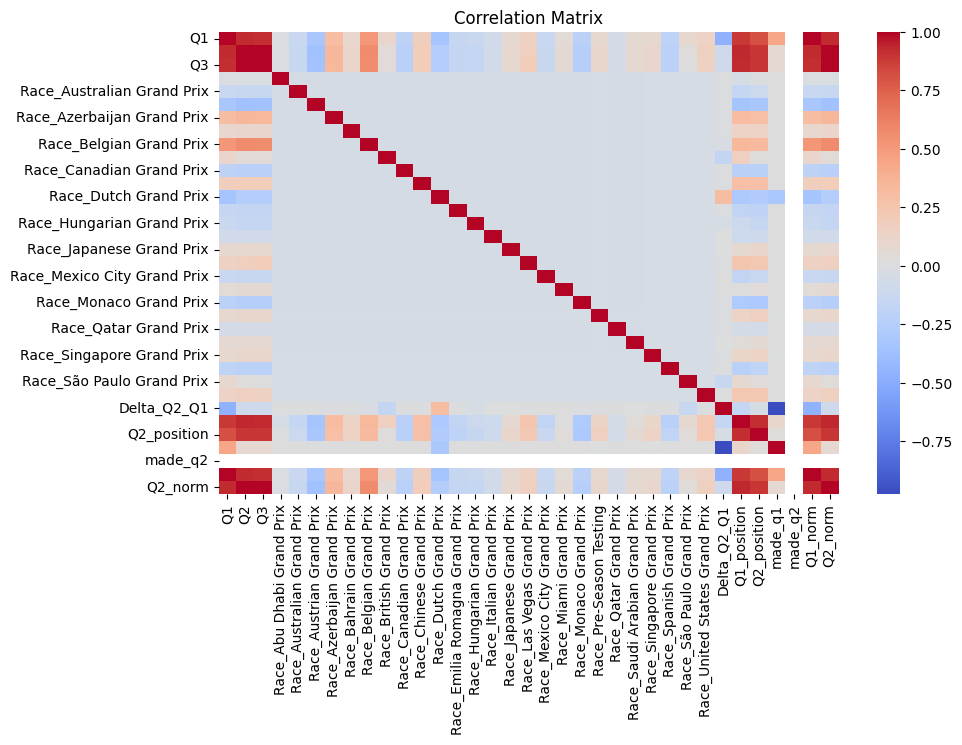

Q2                                4.421718e-01
Q1                                2.937959e-01
Q1_position                       2.244243e-02
Race_Belgian Grand Prix           1.744424e-02
Race_Las Vegas Grand Prix         9.868069e-03
Race_Dutch Grand Prix             8.242279e-03
Race_United States Grand Prix     6.623488e-03
Race_Canadian Grand Prix          5.902345e-03
Race_Chinese Grand Prix           4.319549e-03
Race_Spanish Grand Prix           4.245595e-03
Race_Azerbaijan Grand Prix        3.941227e-03
Race_Austrian Grand Prix          3.532346e-03
Race_Monaco Grand Prix            2.670488e-03
Race_Bahrain Grand Prix           2.212655e-03
Race_Pre-Season Testing           2.197850e-03
Race_Emilia Romagna Grand Prix    2.158555e-03
Race_Singapore Grand Prix         1.765694e-03
Q2_position                       1.318928e-03
Race_Miami Grand Prix             8.115955e-04
Race_Hungarian Grand Prix         8.110184e-04
Race_Mexico City Grand Prix       5.923440e-04
Race_Saudi Ar

In [19]:
# Check if our model is too accurate
corr = df_encoded.corr(numeric_only=True)['Q3'].sort_values(ascending=False)
print(corr.head(10))  # Are any features almost perfectly correlated with Q3?
plt.figure(figsize=(10, 6))
sns.heatmap(df_encoded.corr(numeric_only=True), annot=False, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

from sklearn.inspection import permutation_importance

result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)
importances = pd.Series(result.importances_mean, index=X_test.columns)
print(importances.sort_values(ascending=False))


In [20]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5, scoring='r2')
print("CV R² scores:", scores)
print("Mean:", scores.mean(), "STD:", scores.std())

CV R² scores: [0.99801986 0.95926216 0.99390067 0.99647902 0.89747525]
Mean: 0.9690273914054149 STD: 0.03854323187283966


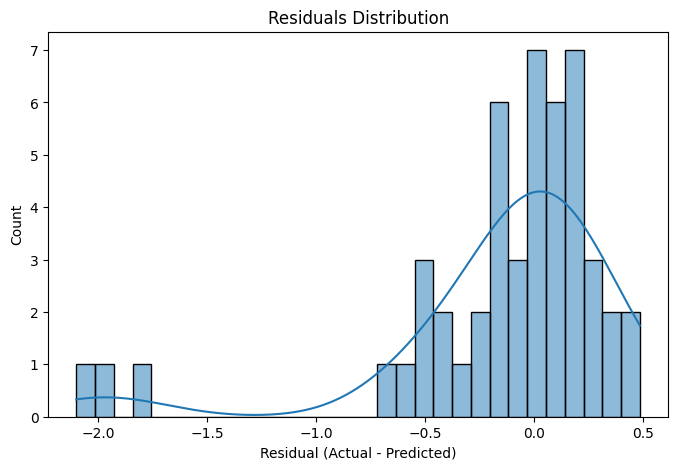

In [21]:
residuals = y_test - y_pred
plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=30, kde=True)
plt.title("Residuals Distribution")
plt.xlabel("Residual (Actual - Predicted)")
plt.show()

In [22]:
# Restart cleanly
df_model = df_qualy.copy()

# Keep only numeric Q1 and Q3
df_model = df_model[df_model['Q3'] > 0]  # Only valid Q3s
df_model['Q1_norm'] = safe_min_max_norm(df_model['Q1'])
df_model['Q1_position'] = df_model.groupby('Race')['Q1'].rank()

# Create features
df_model['made_q1'] = (df_model['Q1'] > 0).astype(int)

# Encode Race (if you want) - OPTIONAL, but be careful
df_model = pd.get_dummies(df_model, columns=['Race'], prefix='Race', dtype=int)

# Drop string/ID columns
df_model = df_model.drop(columns=['Driver'], errors='ignore')

# Drop Q2 entirely — no delta or Q2 position
df_model = df_model.drop(columns=['Q2'], errors='ignore')

# Train
X = df_model.drop(columns=['Q3'])
y = df_model['Q3']

X = X.select_dtypes(include=['number'])  # Just in case


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("R² Score:", r2_score(y_test, y_pred))


R² Score: 0.9964783998200469


In [23]:
print([col for col in X.columns if 'Q2' in col])
print(df_model.corr(numeric_only=True)['Q3'].sort_values(ascending=False))



[]
Q3                                1.000000
Q1                                0.919611
Q1_norm                           0.919611
Race_Belgian Grand Prix           0.565264
Race_Azerbaijan Grand Prix        0.339863
Race_Las Vegas Grand Prix         0.194636
Race_Chinese Grand Prix           0.193345
Race_United States Grand Prix     0.158464
Race_Bahrain Grand Prix           0.106388
Race_Singapore Grand Prix         0.100315
Race_Pre-Season Testing           0.100315
Race_Japanese Grand Prix          0.089286
Race_Saudi Arabian Grand Prix     0.077996
made_q1                           0.077383
Race_Miami Grand Prix             0.071030
Race_British Grand Prix           0.044669
Race_São Paulo Grand Prix         0.014615
Q1_position                      -0.004872
Race_Abu Dhabi Grand Prix        -0.018057
Race_Qatar Grand Prix            -0.055687
Race_Italian Grand Prix          -0.078970
Race_Mexico City Grand Prix      -0.138083
Race_Australian Grand Prix       -0.138130
Race_Hun

### Realization 2 
Theres been an issue, we notice that even with adding engineered features we are running into an issue. The fact that the R2 score is very close to 0.99 even with engineered features and also having removed the driver identity. This is because we realized that if a driver is doing well in Q1 and Q2 they are bound to do well in Q3 as well so the numbers are quite similar thus the correlation when trying to predict will also be very similar 

- Something we can do is shift towards classification model, so we can connect the dots instead 
- Not learning from patterns just exploiting the obvious ones 


In [24]:
# Goal predict if the driver makes it to Q3 or not binary 
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier

df_classification = df_qualy.copy()

# target class
df_classification['made_q3'] = (df_classification['Q3'] > 0).astype(int) 

# dropping columns 
df_classification = df_classification.drop(columns=["Q2", "Q3"])
df_classification = df_classification[df_classification['Q1'] > 0]


# Feature engineering

def safe_min_max_norm(series):
    min_val, max_val = series.min(), series.max()
    return (series - min_val) / (max_val - min_val) if max_val != min_val else pd.Series([0]*len(series), index=series.index)

df_classification['Q1_norm'] = safe_min_max_norm(df_classification['Q1'])


# one hot encoding the categorical variables (Driver and race)
df_classification = pd.get_dummies(df_classification, columns=['Driver', 'Race'], drop_first=True)

# Create the calssification pipiline 
X = df_classification.drop(columns=['made_q3'])
y = df_classification['made_q3']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

# eval the model 
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

from sklearn.model_selection import cross_val_score
scores = cross_val_score(clf, X, y, cv=5, scoring='accuracy')
print("CV Accuracy: ", scores.mean())




              precision    recall  f1-score   support

           0       0.78      0.83      0.80        47
           1       0.84      0.79      0.81        52

    accuracy                           0.81        99
   macro avg       0.81      0.81      0.81        99
weighted avg       0.81      0.81      0.81        99

[[39  8]
 [11 41]]
CV Accuracy:  0.3646670789527932


In [25]:
df_classification['made_q3'].value_counts(normalize=True)


made_q3
0    0.510121
1    0.489879
Name: proportion, dtype: float64

In [27]:
# Trying stratisfied CV because our low CV and high accuracy means overfitting
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(clf, X, y, cv=skf, scoring='accuracy')
print("Stratified CV Accuracy: ", scores.mean())

Stratified CV Accuracy:  0.7835497835497836


In [32]:
# Lets undersatnd what the model is learning with importance
importances = clf.feature_importances_
feature_names = X.columns
feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_df = feat_df.sort_values(by='Importance', ascending=False)
print(feat_df.head(10))

       Feature  Importance
0           Q1    0.159434
1      Q1_norm    0.157520
23  Driver_VER    0.049560
13  Driver_NOR    0.041158
16  Driver_PIA    0.039528
18  Driver_RUS    0.036317
24  Driver_ZHO    0.032382
19  Driver_SAI    0.028786
11  Driver_LEC    0.028779
2   Driver_ALO    0.022954


### Realization 3 
So now our model is a classification model, given the Q1 performance we can determine if a driver will make it to Q3 or not with an accuracy of 81% and cross validation score of around 80%. 
- The cross validation is used to understand how results of our analysis will generalize to independent datasets
- We use this score to evaluate the perfomance of ML models by testing on various subsets of data
- We used Stratisfied K Fold cross validation to evalualte the performance because we had a slight imbalance in the datasets (made_q3)

### Next steps 
We are now going to improve the features in order to properly have a solid model:
- Instead of one-hot encoding our drivers which led to over fitting, we are going to track their Q3 success rate so we can generalize better
- Drop driver one hot columns 
- Trying XGBoost or LightBGM 
    - XGBoost is a gradient boosting algorithm that solves supervised learning problems, combines weak learners (in decision trees) to create a strong learner, iteratively adding new trees where each tree is trained to minimize the error and overall ensemble

In [40]:
# Driver success rate for Q3 

# Extract driver names from one-hot column names
driver_cols = [col for col in df_classification.columns if col.startswith("Driver_")]
race_cols = [col for col in df_classification.columns if col.startswith("Race_")]

# Get driver and race labels
df_classification["Driver"] = df_classification[driver_cols].idxmax(axis=1).str.replace("Driver_", "")
df_classification["Race"] = df_classification[race_cols].idxmax(axis=1).str.replace("Race_", "")

# Create dictioanry of the q3 rate
driver_q3_rate = df_classification.groupby('Driver')['made_q3'].mean().to_dict()
df_classification['driver_q3_rate'] = df_classification['Driver'].map(driver_q3_rate)


# Get the track q3 rate now
track_q3_rate = df_classification.groupby("Race")["made_q3"].mean().to_dict()
df_classification["track_q3_rate"] = df_classification["Race"].map(track_q3_rate)


# Drop the one hot encoded columns 
df_classification = df_classification.drop(columns=[col for col in df_classification.columns if col.startswith("Driver_") or col.startswith("Race_")])


ValueError: attempt to get argmax of an empty sequence

In [41]:
X = df_classification.drop(columns=["made_q3", "Driver", "Race", "Q1"])  # keep Q1_norm or driver_q3_rate, etc.
y = df_classification["made_q3"]

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.71      0.86      0.78        63
           1       0.81      0.64      0.72        61

    accuracy                           0.75       124
   macro avg       0.76      0.75      0.75       124
weighted avg       0.76      0.75      0.75       124



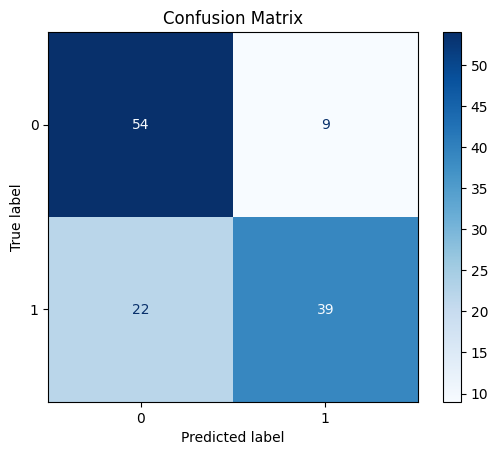

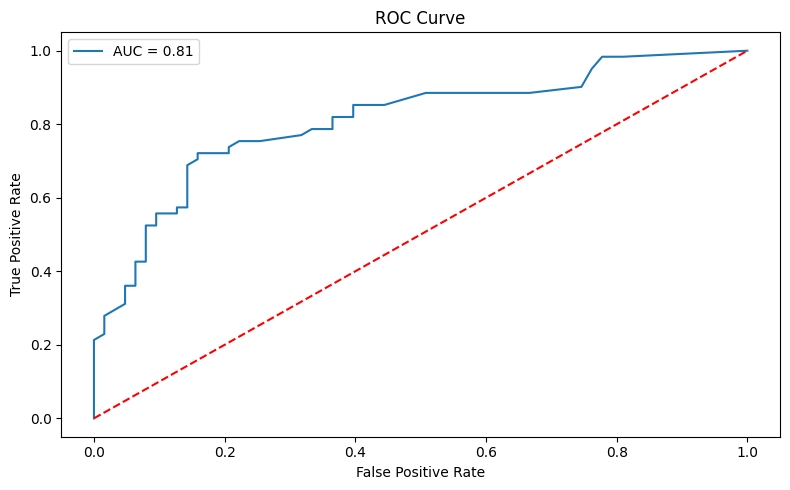

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test, cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

from sklearn.metrics import roc_curve, auc

y_proba = clf.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

# THe AUC of 0.81 here shows thate the model is able to distinguish the classes well,

# the model is better at identifying drivers who didnt make Q3 rather than the ones who did 

In [48]:
# Get the delta to fastest q1 in the entire races
df_classification['fastest_q1_in_race'] = df_classification.groupby('Race')['Q1'].transform('min')
df_classification['delta_to_fastest_q1'] = df_classification['Q1'] - df_classification['fastest_q1_in_race']
df_classification.drop(columns=['fastest_q1_in_race'], inplace=True)

# Driver Q3 entry rate
driver_q3_rate = df_classification.groupby('Driver')['made_q3'].mean().to_dict()
df_classification['driver_q3_entry_rate'] = df_classification['Driver'].map(driver_q3_rate)


# one hot encode 
df_model = pd.get_dummies(df_classification, columns=['Driver', 'Race'], drop_first=True)



In [50]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score


# Train the model again

X = df_model.drop(columns=['made_q3'])  # Drop the target column
y = df_model['made_q3']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

scores = cross_val_score(clf, X, y, cv=5, scoring='accuracy')
print("Stratified CV Accuracy:", scores.mean())
print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, clf.predict_proba(X_test)[:, 1]))



Stratified CV Accuracy: 0.5708307565450423
              precision    recall  f1-score   support

           0       0.71      0.81      0.76        63
           1       0.77      0.66      0.71        61

    accuracy                           0.73       124
   macro avg       0.74      0.73      0.73       124
weighted avg       0.74      0.73      0.73       124

Confusion Matrix:
 [[51 12]
 [21 40]]
ROC AUC Score: 0.8374967473328129


In [51]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(clf, X, y, cv=cv, scoring='accuracy')
print("Stratified CV Accuracy:", scores.mean())


Stratified CV Accuracy: 0.7895279323850752


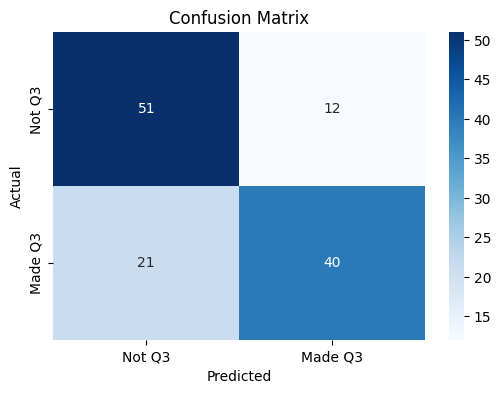

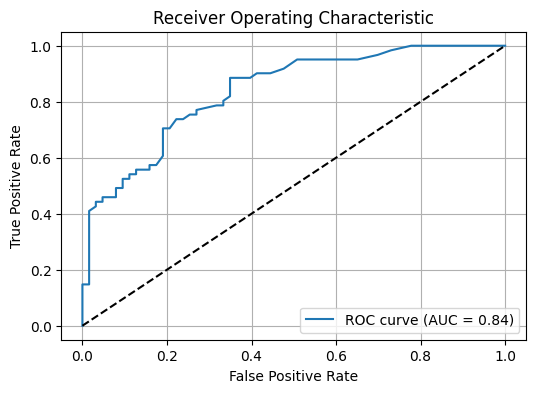

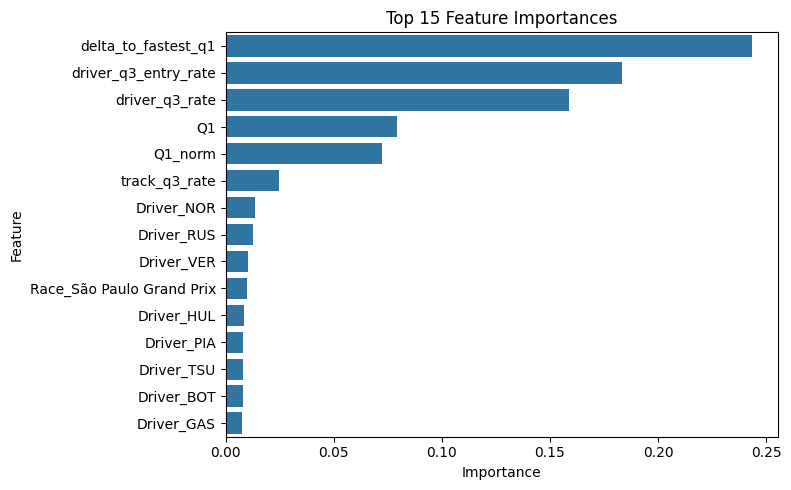

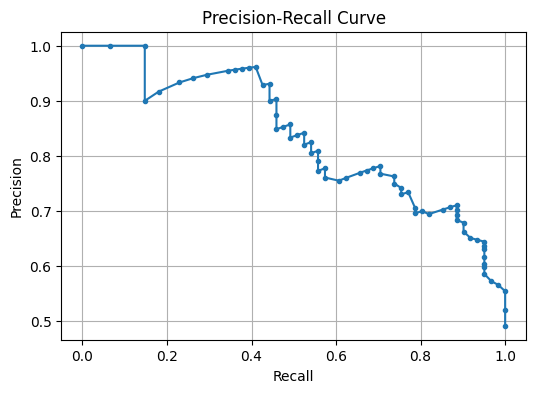

In [52]:
from sklearn.metrics import precision_recall_curve

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Q3', 'Made Q3'], yticklabels=['Not Q3', 'Made Q3'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

y_probs = clf.predict_proba(X_test)[:, 1]  # Get probability for class 1
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.grid()
plt.show()


importances = clf.feature_importances_
feature_names = X.columns
feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_df = feat_df.sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(8,5))
sns.barplot(data=feat_df, x='Importance', y='Feature')
plt.title("Top 15 Feature Importances")
plt.tight_layout()
plt.show()

precision, recall, _ = precision_recall_curve(y_test, y_probs)

plt.figure(figsize=(6,4))
plt.plot(recall, precision, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid()
plt.show()



# Model is performing
### Confusion Matrix
- Based on the confusion matrix above 
    - True Positives (Made Q3 correctly predicted): 40
    - True Negatives (Did not make Q3 correctly predicted): 51
    - False Positives (Predicted Q3 but didn't make it): 12
    - False Negatives (Didn't predict Q3 but they made it): 21
    
We are catching more drivers who dont make Q3 

### ROC Curve (AUC=0.84)
This means the model has a good ability to distinguish between Q3 and non-Q3 drivers

### Top 15 feature importance
* delta_to_fastest_q1 ⬅️ makes total sense: being closer to the fastest lap is critical.

* driver_q3_entry_rate, driver_q3_rate ⬅️ prior performance matters a lot.

* Q1, Q1_norm ⬅️ raw lap time is still a strong feature.

* track_q3_rate ⬅️ Some tracks are just more forgiving or biased.

### Precision-Recall curve

- Strong precision at low recall (i.e., when it does say someone will make Q3, it’s usually correct).

- Starts dropping as recall increases, indicating more false positives creep in as we try to catch more actual Q3 drivers.

✅ Interpretation: Good if you're trying to only highlight high-confidence Q3 predictions (e.g., for betting, commentary, or qualifying analysis).


In [ ]:
print("NaNs in X_train:", X_train.isnull().sum().sum())
print("NaNs in X_test:", X_test.isnull().sum().sum())




NaNs in X_train: 0
NaNs in X_test: 0


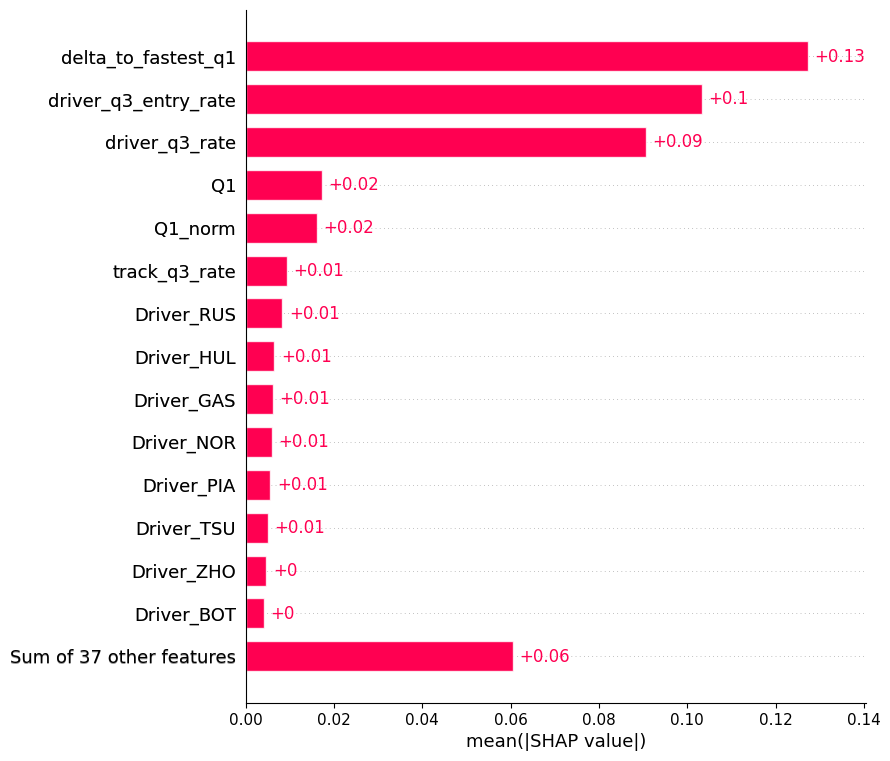

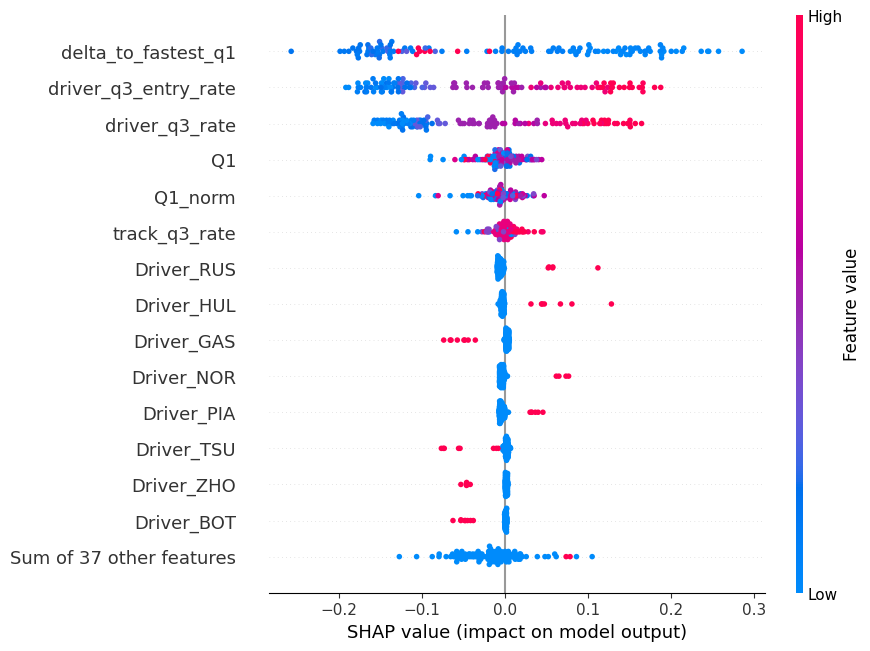

In [75]:
import pandas as pd
import shap
from sklearn.ensemble import RandomForestClassifier

# Step 1: Force all features to numeric
X_train = X_train.apply(pd.to_numeric, errors='coerce')
X_test = X_test.apply(pd.to_numeric, errors='coerce')

# Step 2: Drop any training rows with NaNs
valid_train_idx = X_train.dropna().index
X_train_clean = X_train.loc[valid_train_idx]
y_train_clean = y_train.loc[valid_train_idx]

# Step 3: Drop NaNs from test set and align columns
X_test_clean = X_test[X_train_clean.columns].dropna()

# Step 4: Confirm dtypes are all numeric (force again just in case)
X_train_clean = X_train_clean.astype(float)
X_test_clean = X_test_clean.astype(float)

# Step 5: Refit classifier
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train_clean, y_train_clean)

# Step 6: SHAP analysis using TreeExplainer
explainer = shap.Explainer(clf, X_train_clean)
shap_values = explainer(X_test_clean)

# Extract class 1 SHAP values (shape: 124 x 51)
class1_shap_values = shap_values.values[:, :, 1]

# Attach feature names for proper plotting
shap_values_class1 = shap.Explanation(
    values=class1_shap_values,
    base_values=shap_values.base_values[:, 1],  # class 1 base values
    data=X_test_clean,
    feature_names=X_test_clean.columns
)

# Now plot
shap.plots.bar(shap_values_class1, max_display=15)
shap.plots.beeswarm(shap_values_class1, max_display=15)




